In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
import joblib

pd.set_option("display.max_columns",None)

In [31]:
df1 = pd.read_csv("../dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv")

df2 = pd.read_csv("../dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

df3 = pd.read_csv("../dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

df4 = pd.read_csv("../dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")

df5 = pd.read_csv("../dataset/Tuesday-WorkingHours.pcap_ISCX.csv")

df6 = pd.read_csv("../dataset/Wednesday-workingHours.pcap_ISCX.csv")

In [32]:
df = pd.concat(
    [df1,df2,df3,df4,df5,df6],
    ignore_index=True
)

print(df.shape)

(2130459, 85)


In [33]:
# Remove leading/trailing spaces from all column names
df.columns = df.columns.str.strip()

# Check the cleaned column names
print(df.columns.tolist())

['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH 

In [34]:
drop_columns = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

df.drop(columns=drop_columns, inplace=True)

In [35]:
df["Label"] = df["Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
)

In [36]:
X = df.drop("Label", axis=1)

y = df["Label"]

In [37]:
print(df.dtypes)

Source Port            int64
Destination Port       int64
Protocol               int64
Flow Duration          int64
Total Fwd Packets      int64
                      ...   
Idle Mean            float64
Idle Std             float64
Idle Max             float64
Idle Min             float64
Label                  int64
Length: 81, dtype: object


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130459 entries, 0 to 2130458
Data columns (total 81 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Source Port                  int64  
 1   Destination Port             int64  
 2   Protocol                     int64  
 3   Flow Duration                int64  
 4   Total Fwd Packets            int64  
 5   Total Backward Packets       int64  
 6   Total Length of Fwd Packets  float64
 7   Total Length of Bwd Packets  float64
 8   Fwd Packet Length Max        int64  
 9   Fwd Packet Length Min        int64  
 10  Fwd Packet Length Mean       float64
 11  Fwd Packet Length Std        float64
 12  Bwd Packet Length Max        int64  
 13  Bwd Packet Length Min        int64  
 14  Bwd Packet Length Mean       float64
 15  Bwd Packet Length Std        float64
 16  Flow Bytes/s                 float64
 17  Flow Packets/s               float64
 18  Flow IAT Mean                float64
 19  

In [39]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 2130459
Columns : 81


In [40]:
df.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,56108,3268,6,112740690,32,16,6448.0,1152.0,403,0,201.5,204.724205,72,72,72.0,0.0,67.411331,0.425756,2.398738e+06,5.798698e+06,16400000.0,3.0,113000000.0,3.636796e+06,6.848761e+06,16400000.0,3.0,113000000.0,7516023.200,8323384.915,16400000.0,3.0,1,0,0,0,1024,512,0.283837,0.141919,0,403,163.326531,178.931713,32016.55782,0,1,0,0,1,0,0,0,0,166.729167,201.5,72.0,1024,0,0,0,0,0,0,32,6448,16,1152,377,2079,15,32,3.594286e+02,1.199802e+01,380.0,343.0,16100000.0,4.988048e+05,16400000.0,15400000.0,0
1,42144,389,6,112740560,32,16,6448.0,5056.0,403,0,201.5,204.724205,316,316,316.0,0.0,102.039585,0.425756,2.398735e+06,5.798710e+06,16400000.0,2.0,113000000.0,3.636792e+06,6.848777e+06,16400000.0,2.0,113000000.0,7516016.133,8323376.147,16400000.0,4.0,1,0,0,0,1024,512,0.283838,0.141919,0,403,243.000000,174.716914,30526.00000,0,1,0,0,1,0,0,0,0,248.062500,201.5,316.0,1024,0,0,0,0,0,0,32,6448,16,5056,955,2079,15,32,3.202857e+02,1.574499e+01,330.0,285.0,16100000.0,4.987937e+05,16400000.0,15400000.0,0
2,0,0,0,113757377,545,0,0.0,0.0,0,0,0.0,0.000000,0,0,0.0,0.0,0.000000,4.790898,2.091128e+05,1.395543e+06,20800000.0,0.0,114000000.0,2.091128e+05,1.395543e+06,20800000.0,0.0,0.0,0.000,0.000,0.0,0.0,0,0,0,0,0,0,4.790898,0.000000,0,0,0.000000,0.000000,0.00000,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0,0,0,0,0,0,0,545,0,0,0,-1,-1,0,0,9.361829e+06,7.324646e+06,18900000.0,19.0,12200000.0,6.935824e+06,20800000.0,5504997.0,0
3,63210,5355,17,100126,22,0,616.0,0.0,28,28,28.0,0.000000,0,0,0.0,0.0,6152.248167,219.723149,4.767905e+03,2.183302e+04,100055.0,1.0,100126.0,4.767905e+03,2.183302e+04,100055.0,1.0,0.0,0.000,0.000,0.0,0.0,0,0,0,0,704,0,219.723149,0.000000,28,28,28.000000,0.000000,0.00000,0,0,0,0,0,0,0,0,0,29.272727,28.0,0.0,704,0,0,0,0,0,0,22,616,0,0,-1,-1,21,32,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0
4,0,0,0,54760,4,0,0.0,0.0,0,0,0.0,0.000000,0,0,0.0,0.0,0.000000,73.046019,1.825333e+04,3.046984e+04,53431.0,108.0,54760.0,1.825333e+04,3.046984e+04,53431.0,108.0,0.0,0.000,0.000,0.0,0.0,0,0,0,0,0,0,73.046019,0.000000,0,0,0.000000,0.000000,0.00000,0,0,0,0,0,0,0,0,0,0.000000,0.0,0.0,0,0,0,0,0,0,0,4,0,0,0,-1,-1,0,0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0


In [41]:
missing=df.isnull().sum()

missing=missing[missing>0]

print(missing)

Flow Bytes/s    1274
dtype: int64


In [42]:
print(df.columns.tolist())

['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE F

In [43]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 13968


In [44]:
print(df["Label"].value_counts())

Label
0    1574993
1     555466
Name: count, dtype: int64


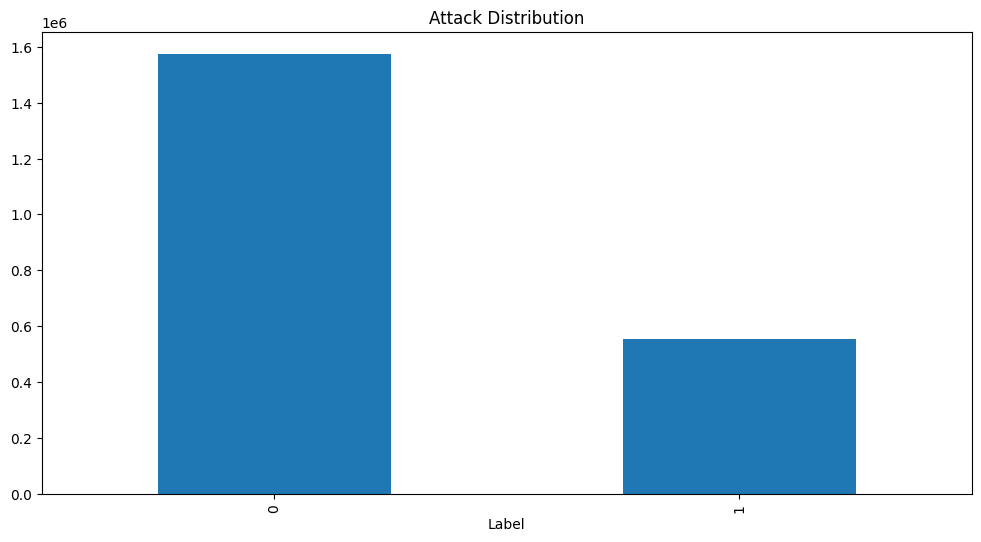

In [45]:
plt.figure(figsize=(12,6))

df["Label"].value_counts().plot(kind="bar")

plt.xticks(rotation=90)

plt.title("Attack Distribution")

plt.show()

In [46]:
df=df.drop_duplicates()

In [47]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)

In [48]:
df=df.dropna()

print(df.shape)

(2114221, 81)


In [50]:
import numpy as np

inf_counts = np.isinf(X).sum()

print(inf_counts[inf_counts > 0])

Flow Bytes/s      1021
Flow Packets/s    2295
dtype: int64


In [51]:
import numpy as np

# Replace infinite values with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

In [52]:
print(X.isnull().sum().sum())


4590


In [53]:
X = X.dropna()

# Keep labels aligned
y = y.loc[X.index]

In [55]:
print("Infinity values:", np.isinf(X).sum().sum())
print("Missing values:", X.isnull().sum().sum())


Infinity values: 0
Missing values: 0


In [56]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

In [57]:
X_scaled=pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [59]:
print(clean_dataset.shape)

(2128164, 81)


In [60]:
clean_dataset=X_scaled.copy()

clean_dataset["Label"]=y.values



In [62]:
from sklearn.model_selection import train_test_split

clean_dataset_sample, _ = train_test_split(
    clean_dataset,
    train_size=300000,
    stratify=clean_dataset["Label"],
    random_state=42
)

print(clean_dataset_sample.shape)

(300000, 81)


In [63]:
clean_dataset_sample.to_csv(
    "../dataset/clean_dataset_sample.csv",
    index=False
)

In [64]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Scaler Saved")

Scaler Saved


In [65]:
clean_dataset.head()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0.680302,-0.240106,-0.694018,2.776659,0.034873,0.007244,0.541665,-0.006612,0.239194,-0.271856,0.676384,0.418711,-0.437912,0.511966,-0.417587,-0.426744,-0.055519,-0.280899,0.232201,0.283376,0.208928,-0.048864,2.797368,0.091430,0.264784,0.213362,-0.110255,3.574020,0.663858,0.954336,0.615845,-0.111012,4.763177,0.0,-0.012167,0.0,0.001336,0.001705,-0.259992,-0.188154,-0.606068,-0.315862,-0.094471,-0.239526,-0.314674,-0.20502,4.763177,-0.016195,-0.678799,1.454191,-0.308906,-0.012167,-0.016224,-0.96723,-0.137399,0.676384,-0.417587,0.001336,0.0,0.0,0.0,0.0,0.0,0.0,0.034873,0.542489,0.007244,-0.006612,-0.464866,0.049665,0.020575,0.002278,-0.127888,-0.101884,-0.149793,-0.104431,0.238124,-0.021370,0.225063,0.231593,0
1,0.033839,-0.405931,-0.694018,2.776655,0.034873,0.007244,0.541665,-0.004677,0.239194,-0.271856,0.676384,0.418711,-0.325799,4.173399,-0.055121,-0.426744,-0.055518,-0.280899,0.232200,0.283377,0.208928,-0.048864,2.797368,0.091430,0.264785,0.213362,-0.110255,3.574020,0.663858,0.954335,0.615845,-0.111012,4.763177,0.0,-0.012167,0.0,0.001336,0.001705,-0.259992,-0.188154,-0.606068,-0.315862,0.142017,-0.245481,-0.315468,-0.20502,4.763177,-0.016195,-0.678799,1.454191,-0.308906,-0.012167,-0.016224,-0.96723,0.084121,0.676384,-0.055121,0.001336,0.0,0.0,0.0,0.0,0.0,0.0,0.034873,0.542489,0.007244,-0.004677,-0.421217,0.049665,0.020575,0.002278,-0.127947,-0.101874,-0.149842,-0.104528,0.238124,-0.021373,0.225063,0.231593,0
2,-1.917214,-0.428337,-1.856759,2.805864,0.801089,-0.010627,-0.050861,-0.007183,-0.273999,-0.271856,-0.293080,-0.234878,-0.470994,-0.568457,-0.524544,-0.426744,-0.055522,-0.280882,-0.269163,-0.230631,0.372751,-0.048865,2.826140,-0.276051,-0.240485,0.376623,-0.110256,-0.346426,-0.208849,-0.246071,-0.278552,-0.111012,-0.209944,0.0,-0.012167,0.0,0.001293,0.001394,-0.259975,-0.188158,-0.606068,-0.493952,-0.579259,-0.492313,-0.331738,-0.20502,-0.209944,-0.016195,-0.678799,-0.687668,-0.308906,-0.012167,-0.016224,-0.96723,-0.591502,-0.293080,-0.524544,0.001293,0.0,0.0,0.0,0.0,0.0,0.0,0.801089,-0.050937,-0.010627,-0.007183,-0.493411,-0.215265,-0.008558,0.002252,13.936668,18.463274,18.234689,-0.104974,0.088252,1.223822,0.389070,-0.152635,0
3,1.009088,-0.119899,1.437675,-0.459109,0.019937,-0.010627,0.005745,-0.007183,-0.238343,0.150502,-0.158365,-0.234878,-0.470994,-0.568457,-0.524544,-0.426744,-0.055284,-0.280059,-0.315953,-0.390992,-0.397961,-0.048865,-0.450968,-0.297959,-0.367766,-0.391446,-0.110256,-0.346426,-0.208849,-0.246071,-0.278552,-0.111012,-0.209944,0.0,-0.012167,0.0,0.001323,0.001394,-0.259129,-0.188158,0.510741,-0.481578,-0.496149,-0.492313,-0.331738,-0.20502,-0.209944,-0.016195,-0.678799,-0.687668,-0.308906,-0

In [68]:
from sklearn.model_selection import train_test_split

# Create a stratified sample of 300,000 rows
clean_dataset_sample, _ = train_test_split(
    clean_dataset,
    train_size=300000,
    stratify=clean_dataset["Label"],
    random_state=42
)

print("Sample Shape:", clean_dataset_sample.shape)

# Save only the sample dataset
clean_dataset_sample.to_csv(
    "../dataset/clean_dataset_sample.csv",
    index=False
)

print("Sample dataset saved successfully!")

Sample Shape: (300000, 81)
Sample dataset saved successfully!
